I actually like this approach. It is exactly how DSP is taught in good universities: Theory → Mathematical Equation → Python Implementation → Result.

I would recommend using one consistent example throughout the notebook instead of changing examples every section. This helps connect all concepts.

# Level 1 – Basic Mathematical Operations

## Example Signals
Throughout this notebook, we will use three signals.

### 1. Speech Signal
A simple speech-like signal can be approximated by a low-frequency sine wave.

**Equation**
$$x_{\text{speech}}(t) = \sin(2\pi f_s t)$$

where:
*   $f_s$ = speech frequency (e.g., 300 Hz)
*   $t$ = time

### 2. Music Signal
Music usually contains many frequencies. For simplicity, we represent it as another sine wave.

**Equation**
$$x_{\text{music}}(t) = 0.8\sin(2\pi f_m t)$$

where:
*   $f_m$ = music frequency (e.g., 800 Hz)

The amplitude is slightly smaller than the speech signal.

### 3. Noise Signal
Noise is random.

**Equation**
$$x_{\text{noise}}(t) = n(t)$$

where:
*   $n(t)$ is a random process (Gaussian white noise in our simulation).

Unlike speech and music, the values of noise cannot be predicted.

## Combined Signal
Suppose a microphone records speech while music is playing in the background and some environmental noise is present. 

The recorded signal is:
$$x_{\text{recorded}}(t) = x_{\text{speech}}(t) + x_{\text{music}}(t) + x_{\text{noise}}(t)$$

This signal will be used throughout the notebook.

# Level 1.1 – Addition of Signals

Signal addition combines two or more signals into a single signal. 

It is commonly used when multiple sound sources are present simultaneously. In real life, microphones naturally record the sum of all sounds arriving at them. For our example, the microphone records speech, music, and background noise.

## Mathematical Equation
For two signals:
$$y(t) = x_1(t) + x_2(t)$$

For our example, this is represented as **Equation A**:
$$\text{Equation A: } x_{\text{recorded}}(t) = x_{\text{speech}}(t) + x_{\text{music}}(t) + x_{\text{noise}}(t)$$

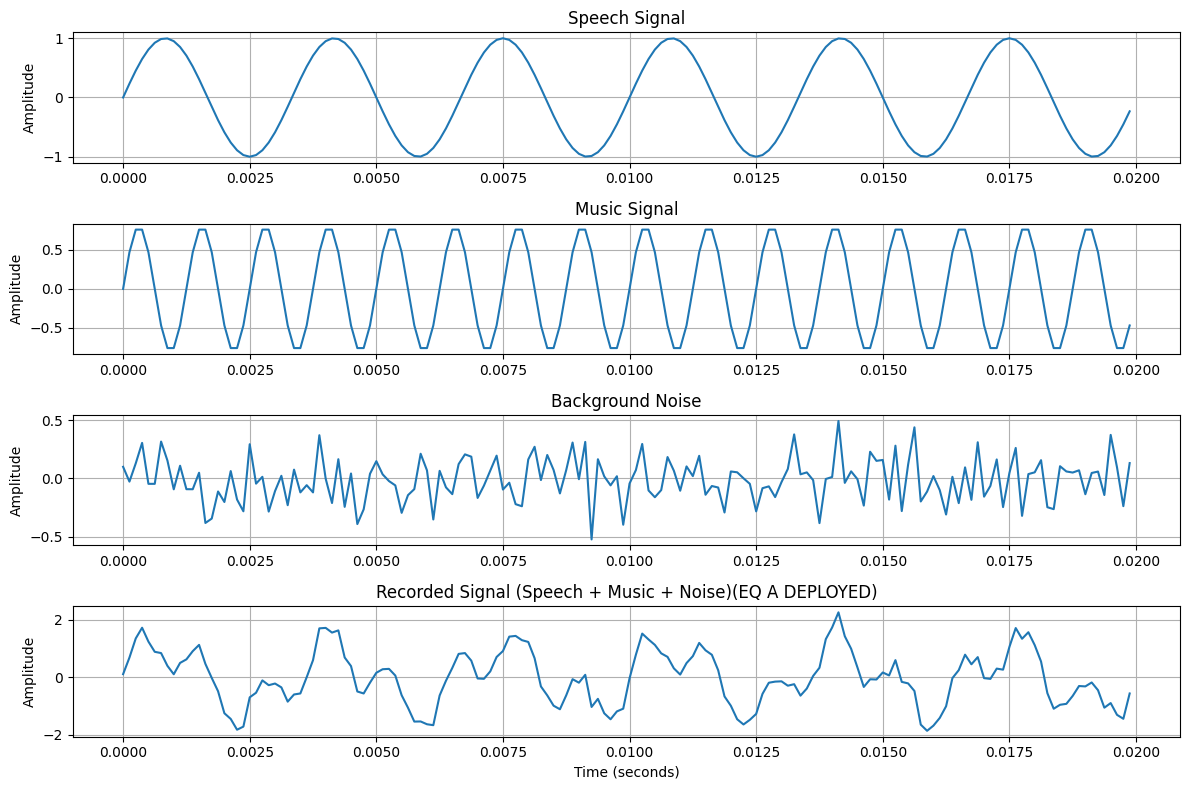

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Signal Parameters
# -------------------------------
fs = 8000                 # Sampling frequency (Hz)
duration = 0.02           # Signal duration (seconds)

# ==============================================================================
# GENERATE THE TIME AXIS (TIMELINE)
# ==============================================================================
# This line creates an array of evenly spaced timestamps for our digital signal.
# 
# 1. int(fs * duration) : Computes total samples (Sampling Rate x Seconds).
# 2. np.linspace(...)   : Generates linearly spaced time values from 0 to 'duration'.
# 3. endpoint=False     : Excludes the final boundary point to ensure perfectly
#                         periodic blocks when stitching audio chunks together.
# ==============================================================================

t = np.linspace(0, duration, int(fs * duration), endpoint=False)


# -------------------------------
# Generate Individual Signals
# -------------------------------

# Speech signal (300 Hz sine wave)

# ==============================================================================
# GENERATE A PURE SINE WAVE (SPEECH SIGNAL SIMULATION)
# ==============================================================================
# Synthesizes a simple 300 Hz tone using the formula: x(t) = sin(2 * pi * f * t)
#
# 1. 300           : The target frequency in Hertz (cycles per second).
# 2. 2 * np.pi * f : Converts frequency from Hz to angular frequency (radians/sec).
# 3. * t           : Multiplies by our time array to compute the phase at each sample.
# 4. np.sin(...)   : Evaluates the sine function to produce the final amplitude array.
# ==============================================================================
speech = np.sin(2 * np.pi * 300 * t)

# ==============================================================================
# GENERATE A PURE SINE WAVE (MUSIC SIGNAL SIMULATION)
# ==============================================================================
# Synthesizes a simple 800 Hz tone using the formula: x(t) = sin(2 * pi * f * t)
#
# 1. 800           : The target frequency in Hertz (cycles per second).
# 2. 2 * np.pi * f : Converts frequency from Hz to angular frequency (radians/sec).
# 3. * t           : Multiplies by our time array to compute the phase at each sample.
# 4. np.sin(...)   : Evaluates the sine function to produce the final amplitude array.
# ==============================================================================
music = 0.8 * np.sin(2 * np.pi * 800 * t)


# ==============================================================================
# GENERATE BACKGROUND NOISE (GAUSSIAN WHITE NOISE)
# ==============================================================================
# Simulates random environmental background noise using a normal distribution.
#
# 1. np.random.seed(42)       : Locks the random number generator so the exact 
#                               same noise array is created every time you run it.
# 2. len(t)                   : Ensures the noise array matches the timeline length.
# 3. np.random.randn(...)     : Generates random values with a mean of 0 and 
#                               a standard deviation of 1.
# 4. 0.2 * ...                : Attenuates (scales down) the noise amplitude so it 
#                               doesn't completely overpower the audio signals.
# ==============================================================================

# Background noise (Gaussian white noise)
np.random.seed(42)        # Makes the noise reproducible
noise = 0.2 * np.random.randn(len(t))

# -------------------------------
# Equation A
# x_recorded(t) = x_speech(t) + x_music(t) + x_noise(t)
# -------------------------------

recorded = speech + music + noise

# -------------------------------
# Plot Results
# -------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(4,1,1) #total rows, total columns, subplot index
plt.plot(t, speech)
plt.title("Speech Signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4,1,2)
plt.plot(t, music)
plt.title("Music Signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4,1,3)
plt.plot(t, noise)
plt.title("Background Noise")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4,1,4)
plt.plot(t, recorded)
plt.title("Recorded Signal (Speech + Music + Noise)(EQ A DEPLOYED)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Level 1.2 – Subtraction of Signals
Signal subtraction removes one signal from another. 

It is widely used in noise cancellation and interference removal. If an estimate of the unwanted signal is available, subtracting it from the recorded signal can recover the desired signal.

## Mathematical Equation
For two signals:
$$y(t) = x_1(t) - x_2(t)$$

Suppose we know the music signal and want to isolate the cleaner speech. This is represented as **Equation B**:
$$\text{Equation B: } x_{\text{clean}}(t) = x_{\text{recorded}}(t) - x_{\text{music}}(t)$$

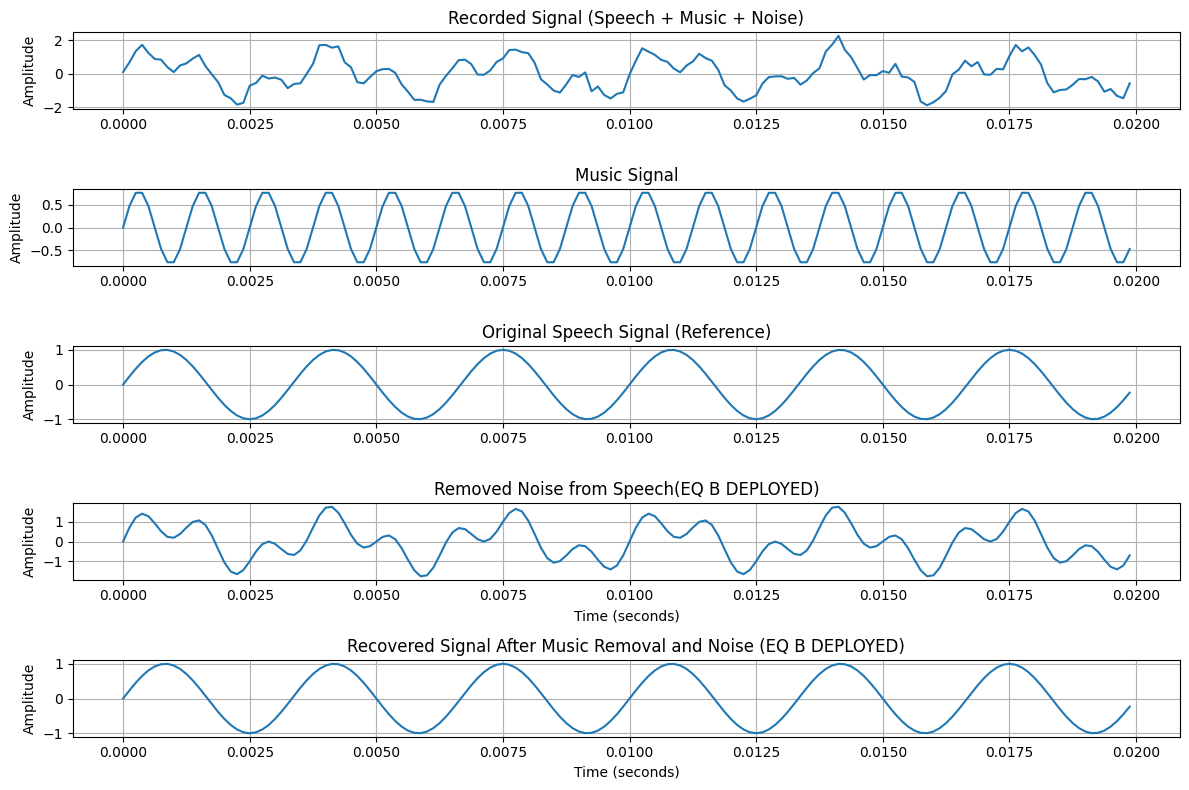

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Signal Parameters
# -------------------------------
fs = 8000                 # Sampling frequency (Hz)
duration = 0.02           # Signal duration (seconds)

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# -------------------------------
# Generate Individual Signals
# -------------------------------

# Speech signal (300 Hz sine wave)
speech = np.sin(2 * np.pi * 300 * t)

# Music signal (800 Hz sine wave)
music = 0.8 * np.sin(2 * np.pi * 800 * t)

# Background noise (Gaussian white noise)
np.random.seed(42)        # Makes the noise reproducible
noise = 0.2 * np.random.randn(len(t))

# -------------------------------
# Create Recorded Signal
# (Equation A from Section 1.1)
# x_recorded(t) = x_speech(t) + x_music(t) + x_noise(t)
# -------------------------------

recorded = speech + music + noise

# -------------------------------
# Equation B
# x_clean(t) = x_recorded(t) - x_music(t)
# -------------------------------

music_speech = recorded - noise
recovered_signal_from_noise_and_music = music_speech - music

# -------------------------------
# Plot Results
# -------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(5,1,1)
plt.plot(t, recorded)
plt.title("Recorded Signal (Speech + Music + Noise)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5,1,2)
plt.plot(t, music)
plt.title("Music Signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5,1,3)
plt.plot(t, speech)
plt.title("Original Speech Signal (Reference)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5,1,4)
plt.plot(t, music_speech)
plt.title("Removed Noise from Speech(EQ B DEPLOYED)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5,1,5)
plt.plot(t, recovered_signal_from_noise_and_music)
plt.title("Recovered Signal After Music Removal and Noise (EQ B DEPLOYED)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Level 1.3 – Multiplication by a Constant (Scaling)

## Theory
Multiplication changes the amplitude of a signal. 

*   If the constant is greater than one, the signal becomes stronger (amplification).
*   If the constant is between zero and one, the signal becomes weaker (attenuation).

The shape and frequency content remain unchanged.

## Mathematical Equation
$$y(t) = a \cdot x(t)$$

where:
*   $a > 1 \rightarrow$ amplification
*   $0 < a < 1 \rightarrow$ attenuation

For our example, amplifying the speech signal is represented as **Equation C**:
$$\text{Equation C: } x_{\text{loud}}(t) = 2x_{\text{speech}}(t)$$

Attenuating the music signal to reduce its volume is represented as **Equation D**:
$$\text{Equation D: } x_{\text{quiet\_music}}(t) = 0.5x_{\text{music}}(t)$$

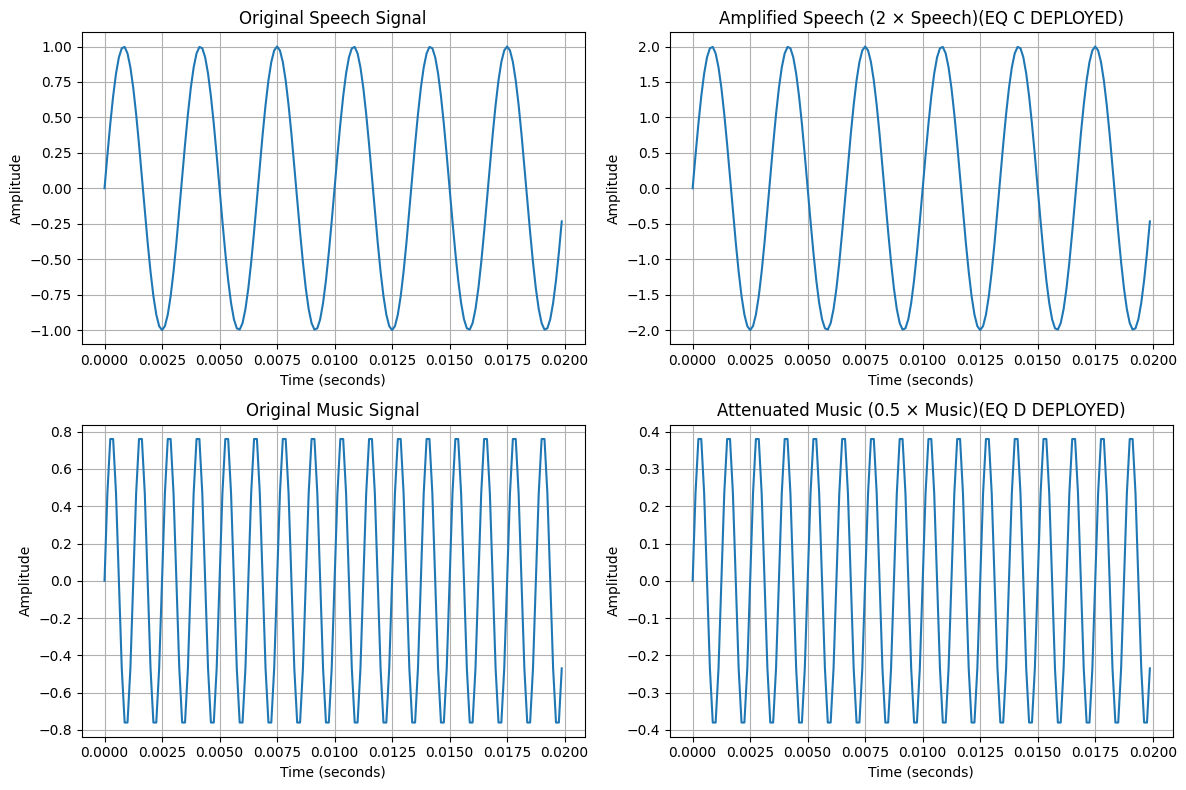

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Signal Parameters
# -------------------------------
fs = 8000                 # Sampling frequency (Hz)
duration = 0.02           # Signal duration (seconds)

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# -------------------------------
# Generate Individual Signals
# -------------------------------

# Speech signal (300 Hz sine wave)
speech = np.sin(2 * np.pi * 300 * t)

# Music signal (800 Hz sine wave)
music = 0.8 * np.sin(2 * np.pi * 800 * t)

# -------------------------------
# Equation C
# x_loud(t) = 2 * x_speech(t)
# (Amplification)
# -------------------------------

loud_speech = 2 * speech

# -------------------------------
# Equation D
# x_quiet_music(t) = 0.5 * x_music(t)
# (Attenuation)
# -------------------------------

quiet_music = 0.5 * music

# -------------------------------
# Plot Results
# -------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(t, speech)
plt.title("Original Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(t, loud_speech)
plt.title("Amplified Speech (2 × Speech)(EQ C DEPLOYED)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(t, music)
plt.title("Original Music Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(t, quiet_music)
plt.title("Attenuated Music (0.5 × Music)(EQ D DEPLOYED)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Level 1.4 – Division
Division is mainly used to compute ratios, averages, and normalize signals. 

Unlike multiplication, it is not usually used directly to amplify or attenuate a signal, because multiplying by the reciprocal is computationally more efficient.

### Typical Applications
*   Normalization
*   Mean calculation
*   Root Mean Square (RMS)
*   Signal-to-Noise Ratio (SNR)

## Mathematical Equations

### Normalization
Scales the signal so its peak value equals 1:
$$\text{Equation E: } x_{\text{norm}}[n] = \frac{x[n]}{\max(|x[n]|)}$$

### Mean
Calculates the average value of the signal over $N$ samples:
$$\text{Equation F: } \mu = \frac{1}{N} \sum_{n=0}^{N-1} x[n]$$

### RMS (Root Mean Square)
Measures the average power or energy level of the signal:
$$\text{Equation G: } \text{RMS} = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x^2[n]}$$

Mean Value : -0.0135
RMS Value  : 0.9372


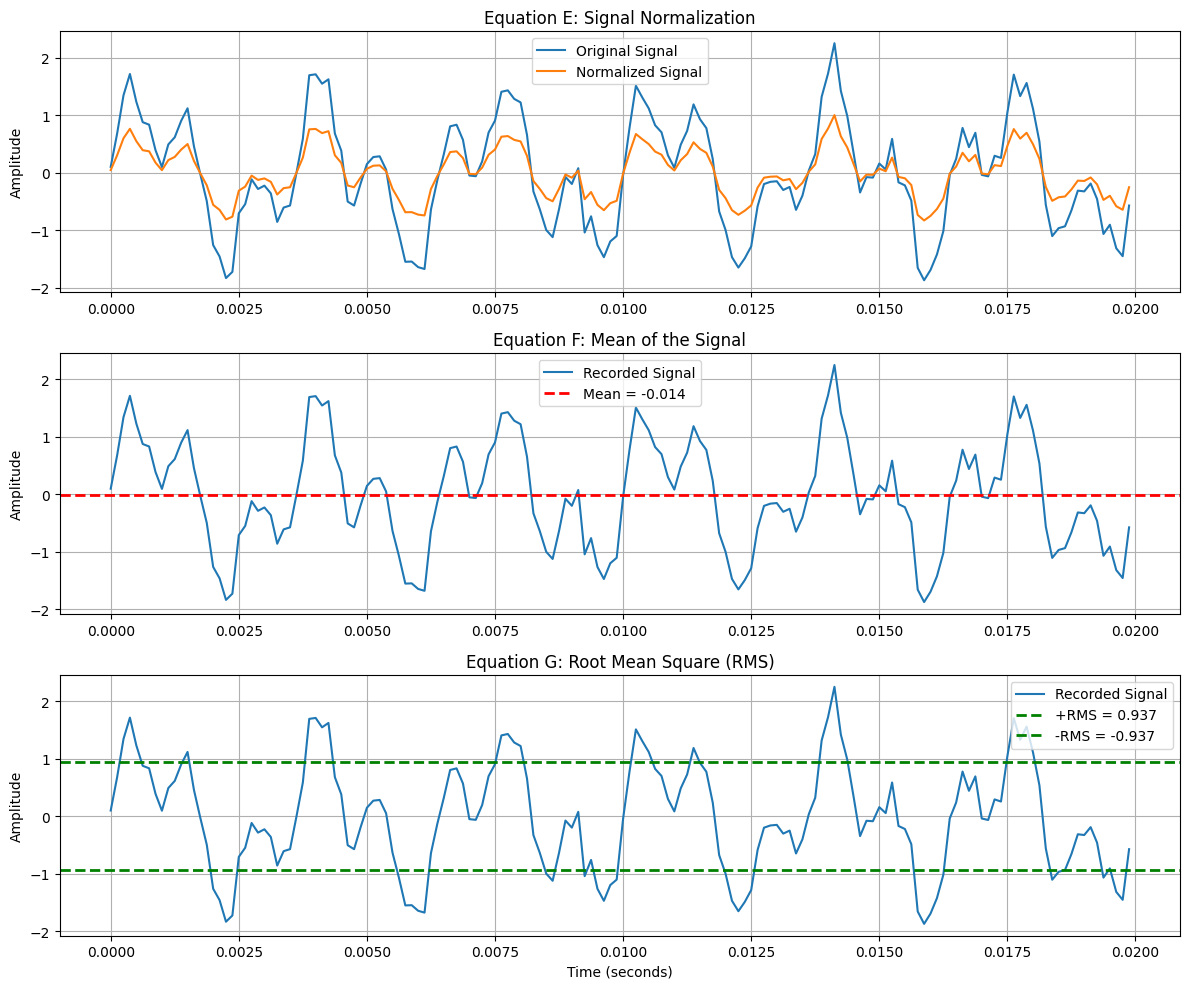

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Signal Parameters
# ---------------------------------------
fs = 8000                 # Sampling frequency (Hz)
duration = 0.02           # Signal duration (seconds)

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# ---------------------------------------
# Generate Signals
# ---------------------------------------
speech = np.sin(2 * np.pi * 300 * t)
music = 0.8 * np.sin(2 * np.pi * 800 * t)

np.random.seed(42)
noise = 0.2 * np.random.randn(len(t))

# Recorded signal
recorded = speech + music + noise

# ---------------------------------------
# Equation E: Normalization
# x_norm[n] = x[n] / max(|x[n]|)
# ---------------------------------------
normalized = recorded / np.max(np.abs(recorded))

# ---------------------------------------
# Equation F: Mean
# μ = (1/N) Σ x[n]
# ---------------------------------------
mean_value = np.mean(recorded)

# ---------------------------------------
# Equation G: RMS
# RMS = sqrt((1/N) Σ x²[n])
# ---------------------------------------
rms_value = np.sqrt(np.mean(recorded ** 2))

# ---------------------------------------
# Display Numerical Results
# ---------------------------------------
print(f"Mean Value : {mean_value:.4f}")
print(f"RMS Value  : {rms_value:.4f}")

# ---------------------------------------
# Visualization
# ---------------------------------------
plt.figure(figsize=(12,10))

# ---------------------------------------
# Equation E - Normalization
# ---------------------------------------
plt.subplot(3,1,1)
plt.plot(t, recorded, label="Original Signal")
plt.plot(t, normalized, label="Normalized Signal")
plt.title("Equation E: Signal Normalization")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# ---------------------------------------
# Equation F - Mean
# ---------------------------------------
plt.subplot(3,1,2)
plt.plot(t, recorded, label="Recorded Signal")
plt.axhline(mean_value,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"Mean = {mean_value:.3f}")
plt.title("Equation F: Mean of the Signal")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# ---------------------------------------
# Equation G - RMS
# ---------------------------------------
plt.subplot(3,1,3)
plt.plot(t, recorded, label="Recorded Signal")

plt.axhline(rms_value,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f"+RMS = {rms_value:.3f}")

plt.axhline(-rms_value,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f"-RMS = {-rms_value:.3f}")

plt.title("Equation G: Root Mean Square (RMS)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

These three operations serve distinct purposes in digital signal processing, helping to prepare data for algorithms, analyze signal behavior, and measure signal strength.

### 1. Why We Do Normalization
Normalization scales the values of a signal to fit within a specific, standardized range (typically between -1 and 1, or 0 and 1).

*   **Prevents Clipping and Distortion:** If you combine multiple audio signals, their amplitudes add up and can exceed the maximum limit of your system (digital clipping). Normalizing ensures the signal stays within safe hardware and playback thresholds.
*   **Standardizes Across Different Recordings:** A speech signal recorded close to a microphone will be much louder than one recorded far away. Normalizing puts both signals on the same volume scale so you can compare or process them equally.
*   **Algorithm Stability:** Many machine learning and DSP algorithms perform poorly or become unstable when inputs have massive differences in scale. Standardizing the range ensures smooth processing.

### 2. Why We Find the Mean
The mean ($\mu$) calculates the average value of all samples in the signal.

*   **Detecting and Removing DC Offset:** In a perfect alternating current (AC) signal like audio, the wave should oscillate symmetrically around zero, meaning the mean should be $0$. If the mean is not $0$, the signal has a "DC offset" (a constant vertical shift). DC offset wastes system headroom and causes audible clicks at the beginning and end of audio playback, so calculating the mean is the first step to subtracting it out.
*   **Establishing a Baseline:** It provides the central reference point from which fluctuations occur.

### 3. Why We Find the RMS (Root Mean Square)
The RMS value calculates the effective power or energy level of a signal. You cannot use a simple average (mean) to measure a signal's overall strength because the positive and negative halves of a wave cancel each other out, resulting in a mean near zero.

*   **Measures Perceived Loudness:** Human ears do not judge volume based on the single highest peak of a sound wave; they judge it based on the continuous average energy. RMS perfectly tracks this perceived power.
*   **Quantifies Noise and Signal Strength:** RMS is heavily used to compute the Signal-to-Noise Ratio (SNR). By calculating the RMS of your clean signal and comparing it to the RMS of the noise floor, you get an accurate metric of how degraded your signal is.

--- Signal Metrics ---
Original Peak Value: 2.2504
Normalized Peak Value: 1.0000
Signal Mean (DC Offset): -0.0135
Signal RMS (Power Level): 0.9372


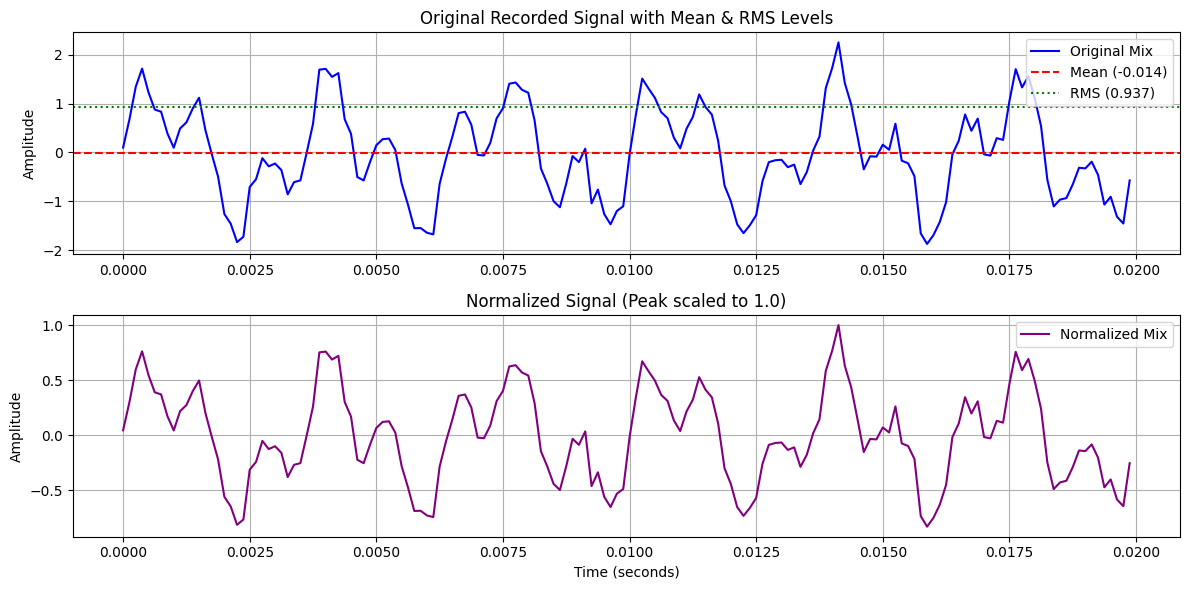

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Base Setup (Same Example)
# -------------------------------
fs = 8000 
duration = 0.02
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

speech = np.sin(2 * np.pi * 300 * t)
music = 0.8 * np.sin(2 * np.pi * 800 * t)
np.random.seed(42)
noise = 0.2 * np.random.randn(len(t))

# Our baseline combined signal
recorded = speech + music + noise

# -------------------------------
# 2. Math Operations (Calculations)
# -------------------------------

# Equation E: Normalization (Scales peak to exactly 1.0 or -1.0)
recorded_norm = recorded / np.max(np.abs(recorded))

# Equation F: Mean (Checks for DC offset)
recorded_mean = np.mean(recorded)

# Equation G: RMS (Measures total average power/energy)
recorded_rms = np.sqrt(np.mean(recorded**2))

# -------------------------------
# 3. Print the Metrics
# -------------------------------
print(f"--- Signal Metrics ---")
print(f"Original Peak Value: {np.max(np.abs(recorded)):.4f}")
print(f"Normalized Peak Value: {np.max(np.abs(recorded_norm)):.4f}")
print(f"Signal Mean (DC Offset): {recorded_mean:.4f}")
print(f"Signal RMS (Power Level): {recorded_rms:.4f}")

# -------------------------------
# 4. Plot Comparison
# -------------------------------
plt.figure(figsize=(12, 6))

# Plot Original Recorded Signal
plt.subplot(2, 1, 1)
plt.plot(t, recorded, color='b', label='Original Mix')
plt.axhline(recorded_mean, color='r', linestyle='--', label=f'Mean ({recorded_mean:.3f})')
plt.axhline(recorded_rms, color='g', linestyle=':', label=f'RMS ({recorded_rms:.3f})')
plt.title("Original Recorded Signal with Mean & RMS Levels")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)

# Plot Normalized Signal
plt.subplot(2, 1, 2)
plt.plot(t, recorded_norm, color='purple', label='Normalized Mix')
plt.title("Normalized Signal (Peak scaled to 1.0)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Level 1.5 – Time Shifting (Delay and Advance)

## Theory
Time shifting moves a signal along the time axis without altering its shape or frequency content. It is one of the most critical foundational operations in DSP. Digital filters, echoes, reverberation, convolution, and many complex algorithms are built entirely by combining shifted versions of a signal.

There are two directional cases of time shifting:
*   **Delay (Right Shift):** Moves the signal forward into the future, meaning the current output depends on past inputs.
*   **Advance (Left Shift):** Moves the signal backward into the past, meaning the output depends on future inputs (used in non-real-time or offline processing).

### Typical Applications
*   Finite Impulse Response (FIR) and Infinite Impulse Response (IIR) filters
*   Echo and reverb generation
*   Correlation and Convolution

## Mathematical Equation
The general equation for a time shift is:
$$y[n] = x[n - k]$$

Where the value of $k$ determines the type of shift:

### Delay (Right Shift, $k > 0$)
Shifts the signal backward by $D$ samples:
$$\text{Equation H: } y[n] = x[n - D], \quad D > 0$$

### Advance (Left Shift, $k < 0$)
Shifts the signal forward by $D$ samples:
$$\text{Equation I: } y[n] = x[n + D], \quad D > 0$$

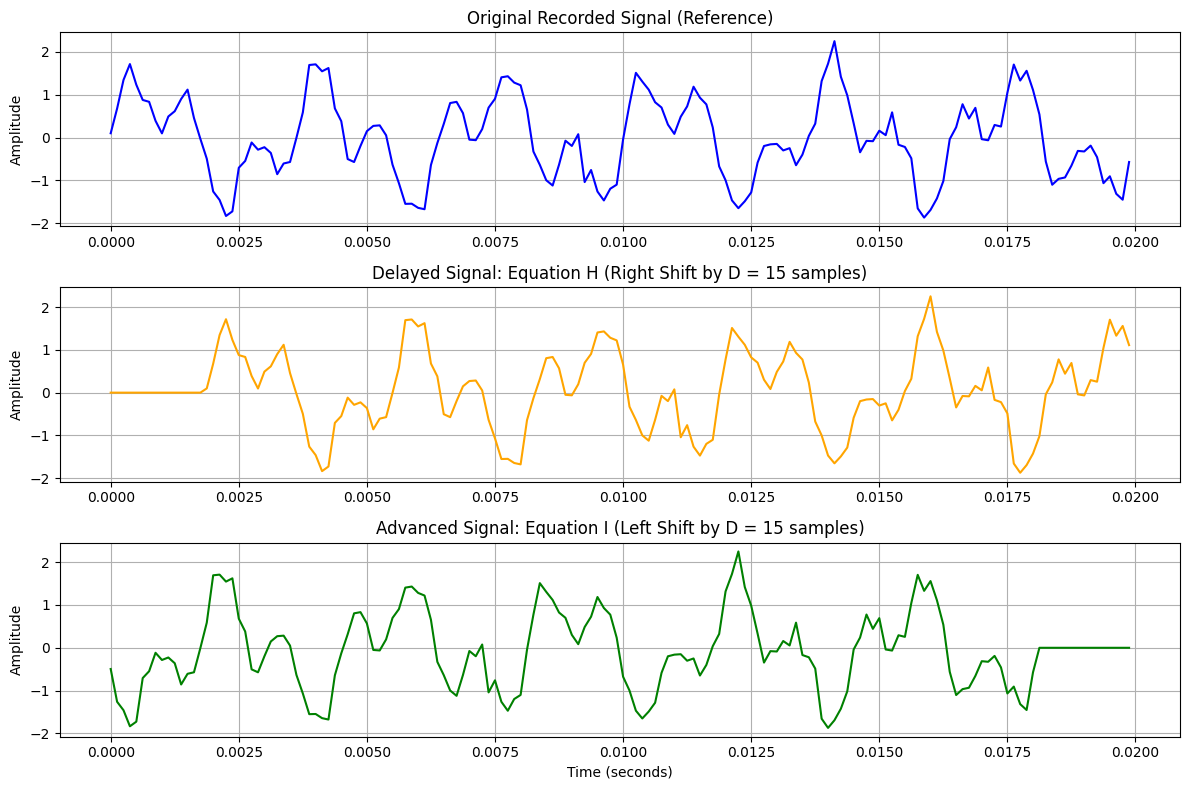

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Base Setup (Consistent Example)
# -------------------------------
fs = 8000 
duration = 0.02
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

speech = np.sin(2 * np.pi * 300 * t)
music = 0.8 * np.sin(2 * np.pi * 800 * t)
np.random.seed(42)
noise = 0.2 * np.random.randn(len(t))

# Baseline recorded signal
recorded = speech + music + noise

# -------------------------------
# 2. Time Shifting Calculations
# -------------------------------
# Define shift amount in samples (e.g., D = 15 samples)
D = 15 

# Equation H: Delay (Right Shift, k > 0)
# Shift values to the right, pad the beginning with zeros
recorded_delayed = np.zeros_like(recorded)
recorded_delayed[D:] = recorded[:-D]

# Equation I: Advance (Left Shift, k < 0)
# Shift values to the left, pad the end with zeros
recorded_advanced = np.zeros_like(recorded)
recorded_advanced[:-D] = recorded[D:]

# -------------------------------
# 3. Plotting results
# -------------------------------
plt.figure(figsize=(12, 8))

# Original Signal Reference
plt.subplot(3, 1, 1)
plt.plot(t, recorded, color='b')
plt.title("Original Recorded Signal (Reference)")
plt.ylabel("Amplitude")
plt.grid(True)

# Delayed Signal Plot
plt.subplot(3, 1, 2)
plt.plot(t, recorded_delayed, color='orange')
plt.title(f"Delayed Signal: Equation H (Right Shift by D = {D} samples)")
plt.ylabel("Amplitude")
plt.grid(True)

# Advanced Signal Plot
plt.subplot(3, 1, 3)
plt.plot(t, recorded_advanced, color='green')
plt.title(f"Advanced Signal: Equation I (Left Shift by D = {D} samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

In audio and signal processing, shifting signals left or right serves essential practical and mathematical purposes. Because time moves forward from left to right on a graph, these shifts represent how we manipulate the timing of sounds.

### 1. Why We Use Right Shifts (Delays)
Right shifting means moving a signal later in time. Since it only requires past data, it can be done in **real-time**.

*   **Creating Audio Effects:** Echo and reverberation (reverb) are created by taking an audio signal, shifting it to the right by a few milliseconds, and mixing it back with the original sound.
*   **Acoustic Time Alignment:** In live concerts, speakers at the front of the stage and speakers halfway back the stadium cannot play at the exact same instant. Because sound travels slowly through the air, the sound from the front takes time to reach the back. Engineers right-shift (delay) the audio going to the stadium's rear speakers so the sound waves hit the audience's ears at the exact same time as the sound from the front.
*   **Digital Filters (FIR and IIR):** Digital filters smooth out noise or shape the equalizer (EQ) of audio by combining the current sample with right-shifted (past) samples.

### 2. Why We Use Left Shifts (Advances)
Left shifting means moving a signal earlier in time. In the real world, you cannot look into the future, so left shifts **cannot be done in real-time live audio**. However, they are incredibly useful in **offline processing** (editing a pre-recorded file).

*   **Look-Ahead Dynamic Processing:** If you are mastering a recorded track and want to prevent a sudden loud drum hit from clipping, a digital limiter can left-shift the audio profile. This allows the system to "look ahead" into the future of the file, see the loud peak coming, and smoothly turn down the volume *before* the loud sound actually plays.
*   **Aligning Multi-Track Recordings:** If two different microphones record the same guitar—one close to the amp and one across the room—the room mic will be naturally delayed due to the speed of sound. In a digital audio workstation (DAW), you can left-shift (advance) the room mic track to perfectly align it with the close mic, removing phase cancellation.
*   **Mathematical Operations (Convolution & Correlation):** Algorithms that search for a specific sound pattern within a longer recording shift signals left and right across each other to find the exact moment where the waveforms match up perfectly.

# Level 1.6 – Time Reversal (Optional but Fundamental)

Time reversal flips a signal along the time axis, effectively playing it backward from end to start. 

While it is less common as a standalone real-time effect, it serves as a critical mathematical building block for core signal processing operations.

### Typical Applications
*   Correlation
*   Matched filtering
*   Derivation of convolution

## Mathematical Equation
$$\text{Equation J: } y[n] = x[-n]$$

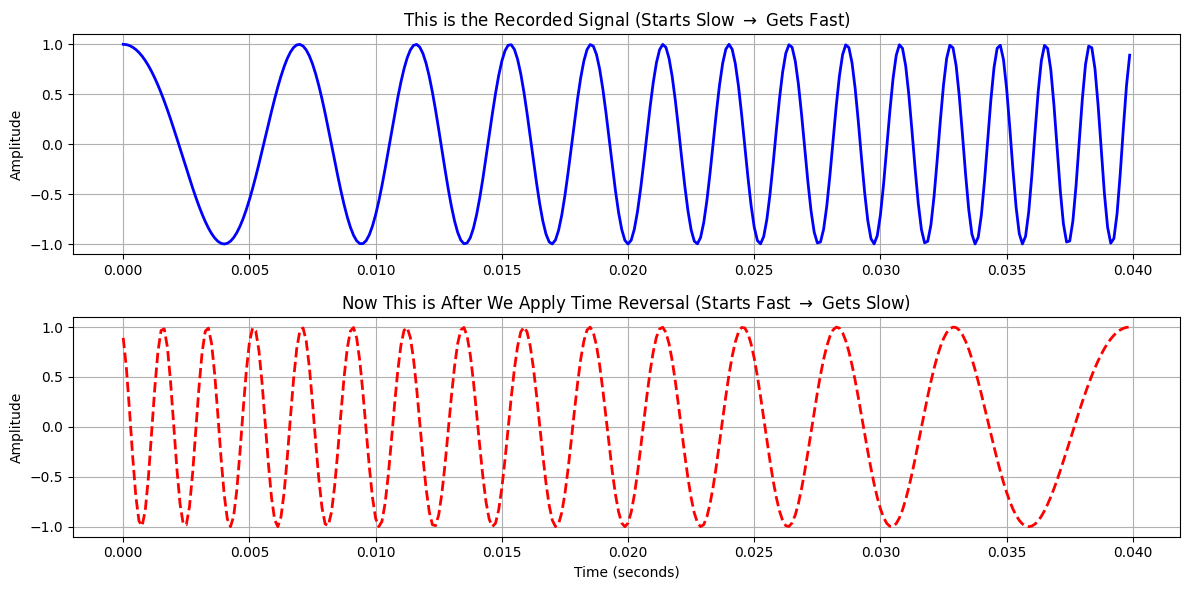

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Base Setup: Generate an Asymmetric Recorded Signal
# ------------------------------------------------------------------------------
fs = 8000 
duration = 0.04  
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# We use a linear chirp (100 Hz to 600 Hz) so the left and right sides are different.
# This makes the time reversal visually obvious (unlike a uniform sine wave).
f0 = 100
f1 = 600
phase = 2 * np.pi * (f0 + (f1 - f0) * t / (2 * duration)) * t
recorded_signal = np.cos(phase)

# ------------------------------------------------------------------------------
# 2. Level 1.7 – Time Reversal (Equation J)
# ------------------------------------------------------------------------------
# Equation J: y[n] = x[-n]
# Using basic Python/NumPy slicing [::-1] to completely reverse the sample array.
reversed_signal = recorded_signal[::-1]

# ------------------------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot 1: The Original Input
plt.subplot(2, 1, 1)
plt.plot(t, recorded_signal, color='b', linewidth=2)
plt.title("This is the Recorded Signal (Starts Slow $\\rightarrow$ Gets Fast)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot 2: After Time Reversal
plt.subplot(2, 1, 2)
plt.plot(t, reversed_signal, color='r', linestyle='--', linewidth=2)
plt.title("Now This is After We Apply Time Reversal (Starts Fast $\\rightarrow$ Gets Slow)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

### Where We Use It in Audio and Acoustics
Time reversal is used exclusively in **offline audio processing**—meaning software applications working on pre-recorded audio files where the computer can scan the entire file at once (like in a Digital Audio Workstation).

*   **Audio Mastering and EQing:** When using digital equalizers (EQ) and noise-reduction plugins to clean up recorded tracks.
*   **Room Acoustics Measurement:** When analyzing how sound bounces around a concert hall, stadium, or recording studio to map out reflections and echoes.
*   **Acoustic Echo Cancellation:** When processing recorded multi-microphone setups to isolate a speaker's voice from ambient room reflections.

---

### Why We Use It in Audio and Acoustics
The fundamental reason we use time reversal comes down to two simple acoustic engineering goals:

#### 1. Cleaning Audio Without Smearing the Sound (Zero-Phase Filtering)
Every standard digital filter (like a low-pass filter used to hiss-remove a vocal track) has a direction: it moves forward from left to right. As it filters out the noise, it physically drags the audio samples backward, causing a tiny time delay. Because different frequencies get delayed by different amounts, the timing of your audio gets smeared, making the mix sound muddy.

By flipping the recorded audio completely backward, running it through the filter a second time, and flipping it back to normal, the two directional delays perfectly subtract and cancel each other out. You get a perfectly crisp, noise-free track where every transient and frequency peak lines up exactly where it originally belonged.

#### 2. Isolating a Specific Sound Buried in Room Noise (Matched Filtering)
If you record a short acoustic pulse (like a starter pistol snap used to test a stadium's acoustics) but the recording is buried under heavy environmental noise or crowd chatter, standard audio math requires you to flip a clean template of that pulse backward first.

When you slide the noisy recording past this pre-flipped template, the random background noise cancels out. The true, hidden acoustic pulse locks in perfectly with its reversed mirror image like puzzle pieces, collapsing the scattered sound energy into one single, massive volume spike. This instantly tells the software exactly when the sound waves arrived.

# Level 1.7 – Time Scaling (Continuous-Time)

Time scaling compresses or stretches a signal along the time axis. 

The core difference between time scaling and amplitude scaling (multiplication by a constant) comes down to which axis you are modifying:
*   **Amplitude Scaling (Level 1.3):** Modifies the vertical **y-axis** (changes the volume or signal strength).
*   **Time Scaling:** Modifies the horizontal **x-axis** (changes the speed or duration of the signal).

### Typical Applications
*   **Playback Speed Control:** Speeding up or slowing down audio or video files.
*   **Signal Analysis:** Stretching fast transient signals to analyze their behavior.
*   **Time-Frequency Processing:** Altering signal duration in advanced transform domains.

## Mathematical Equation
$$y(t) = x(at)$$

Where the value of the scaling factor $a$ determines the effect:

### Time Compression ($a > 1$)
The signal is compressed along the time axis, causing it to play back **faster**:
$$\text{Equation K: } y(t) = x(2t) \quad (\text{Plays at } 2\times \text{ speed})$$

### Time Expansion ($0 < a < 1$)
The signal is stretched out along the time axis, causing it to play back **slower**:
$$\text{Equation L: } y(t) = x(0.5t) \quad (\text{Plays at } 0.5\times \text{ speed})$$

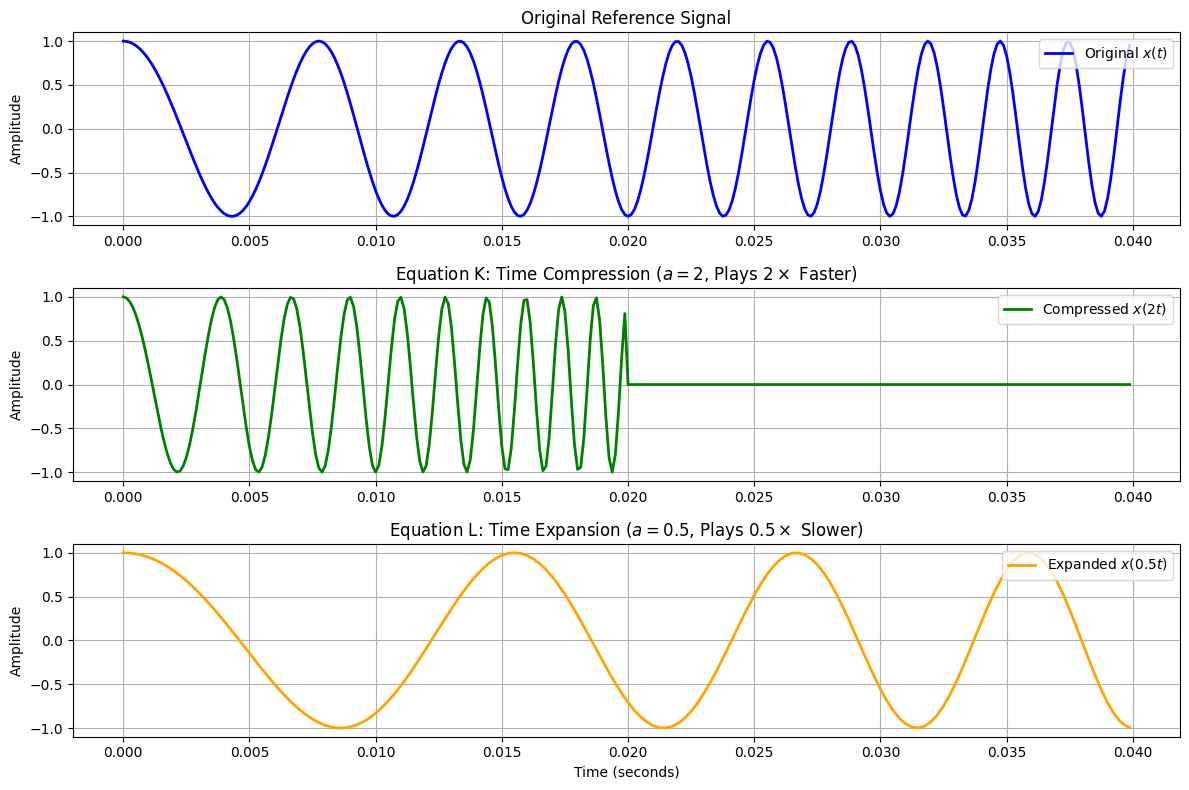

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. Base Setup: Generate the Original Signal x(t)
# ------------------------------------------------------------------------------
fs = 8000 
duration = 0.04  
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# A linear chirp ensures speed changes are instantly visible by tracking the frequency
f0 = 100
f1 = 400
phase = 2 * np.pi * (f0 + (f1 - f0) * t / (2 * duration)) * t
x_original = np.cos(phase)

# ------------------------------------------------------------------------------
# 2. Equation K: Time Compression (a = 2) -> Plays 2x Faster
# ------------------------------------------------------------------------------
# Mathematically: y(t) = x(2t). Time moves twice as fast, so the signal finishes 
# in half the original window.
t_compressed = 2 * t
# Interpolate back onto the original time grid to observe the speed change
y_compressed = np.interp(t_compressed, t, x_original, left=0, right=0)

# ------------------------------------------------------------------------------
# 3. Equation L: Time Expansion (a = 0.5) -> Plays 0.5x Slower
# ------------------------------------------------------------------------------
# Mathematically: y(t) = x(0.5t). Time moves at half speed, so the signal stretches
# out to fill double the duration.
t_expanded = 0.5 * t
# Interpolate back onto the original time grid to observe the stretched wave
y_expanded = np.interp(t_expanded, t, x_original, left=0, right=0)

# ------------------------------------------------------------------------------
# 4. Visualization
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Plot 1: Original Signal
plt.subplot(3, 1, 1)
plt.plot(t, x_original, color='b', linewidth=2, label='Original $x(t)$')
plt.title("Original Reference Signal")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right')

# Plot 2: Time Compression (Equation K)
plt.subplot(3, 1, 2)
plt.plot(t, y_compressed, color='g', linewidth=2, label='Compressed $x(2t)$')
plt.title("Equation K: Time Compression ($a = 2$, Plays $2\\times$ Faster)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right')

# Plot 3: Time Expansion (Equation L)
plt.subplot(3, 1, 3)
plt.plot(t, y_expanded, color='orange', linewidth=2, label='Expanded $x(0.5t)$')
plt.title("Equation L: Time Expansion ($a = 0.5$, Plays $0.5\\times$ Slower)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# EXPERIMENTS


In [2]:
import time
import numpy as np
import sounddevice as sd

# ------------------------------------------------------------------------------
# 1. Configuration Setup
# ------------------------------------------------------------------------------
fs = 44100          # High-quality sample rate for clear voice recording
duration = 10.0      # Record for 10 seconds
scaling_factor = 0.8 # 0.5x = half speed / slowed down

# ------------------------------------------------------------------------------
# 2. Record Audio directly from Microphone to RAM
# ------------------------------------------------------------------------------
print("\n🎤 MICROPHONE OPENING IN 1 SECOND...")
time.sleep(1)

print("🔴 RECORDING STARTED! Speak, make noise, or play a sound now...")
# Records as a 2D float32 array (samples, channels)
audio_captured = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype='float32')
sd.wait()  # Wait until the 10 seconds are fully complete
print("⏹️ RECORDING FINISHED.")

# Flatten to a 1D array for easier math manipulation
x_original = audio_captured.flatten()

# ------------------------------------------------------------------------------
# 3. Apply Time Expansion (Mathematical Scaling: y(t) = x(a*t))
# ------------------------------------------------------------------------------
print("\n⏳ Processing audio via time-scaling transformation...")

# Create the original time vector representing the 10-second capture
t_original = np.linspace(0, duration, len(x_original), endpoint=False)

# The new duration will stretch out (10s / 0.5 = 20 seconds long)
expanded_duration = duration / scaling_factor
t_expanded_grid = np.linspace(0, expanded_duration, int(fs * expanded_duration), endpoint=False)

# Map the expanded grid back to the original timeline using interpolation
y_expanded = np.interp(scaling_factor * t_expanded_grid, t_original, x_original)

# ------------------------------------------------------------------------------
# 4. Immediate Dynamic Playback
# ------------------------------------------------------------------------------
print(f"🔊 PLAYING BACK TIME-SCALED AUDIO ({expanded_duration} seconds)...")
sd.play(y_expanded, samplerate=fs)
sd.wait()  # Wait until playback finishes before ending the script
print("✅ Playback finished. Memory cleared.")


🎤 MICROPHONE OPENING IN 1 SECOND...
🔴 RECORDING STARTED! Speak, make noise, or play a sound now...
⏹️ RECORDING FINISHED.

⏳ Processing audio via time-scaling transformation...
🔊 PLAYING BACK TIME-SCALED AUDIO (12.5 seconds)...
✅ Playback finished. Memory cleared.


## QR CODE GENERATION

In [4]:
import qrcode
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers.pil import RoundedModuleDrawer
from qrcode.image.styles.colormasks import RadialGradiantColorMask

def generate_beautiful_qr():
    # 1. Take input from the user
    print("✨ Beautiful QR Code Generator ✨")
    user_input = input("Paste your link or text here and press Enter:\n> ").strip()
    
    if not user_input:
        print("❌ Error: No text or link provided.")
        return

    # 2. Configure the QR code parameters
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_H,  # High correction allows for stylized shapes
        box_size=15,                                         # Size of each individual square pixel
        border=4,                                           # Clean white border spacing
    )
    
    qr.add_data(user_input)
    qr.make(fit=True)

    # 3. Apply style treatments (Rounded dots and a deep midnight-blue to black gradient)
    print("\n🎨 Designing your QR code...")
    beautiful_img = qr.make_image(
        image_factory=StyledPilImage,
        module_drawer=RoundedModuleDrawer(),
        color_mask=RadialGradiantColorMask(
            back_color=(255, 255, 255),       # Crisp white background
            center_color=(20, 30, 45),        # Deep slate blue center
            edge_color=(0, 0, 0)              # Pure black edges
        )
    )

    # 4. Save the finished image
    output_filename = "beautiful_qrcode.png"
    beautiful_img.save(output_filename)
    print(f"✅ Success! Your QR code has been saved to your folder as: {output_filename}")

if __name__ == "__main__":
    generate_beautiful_qr()

✨ Beautiful QR Code Generator ✨

🎨 Designing your QR code...
✅ Success! Your QR code has been saved to your folder as: beautiful_qrcode.png
